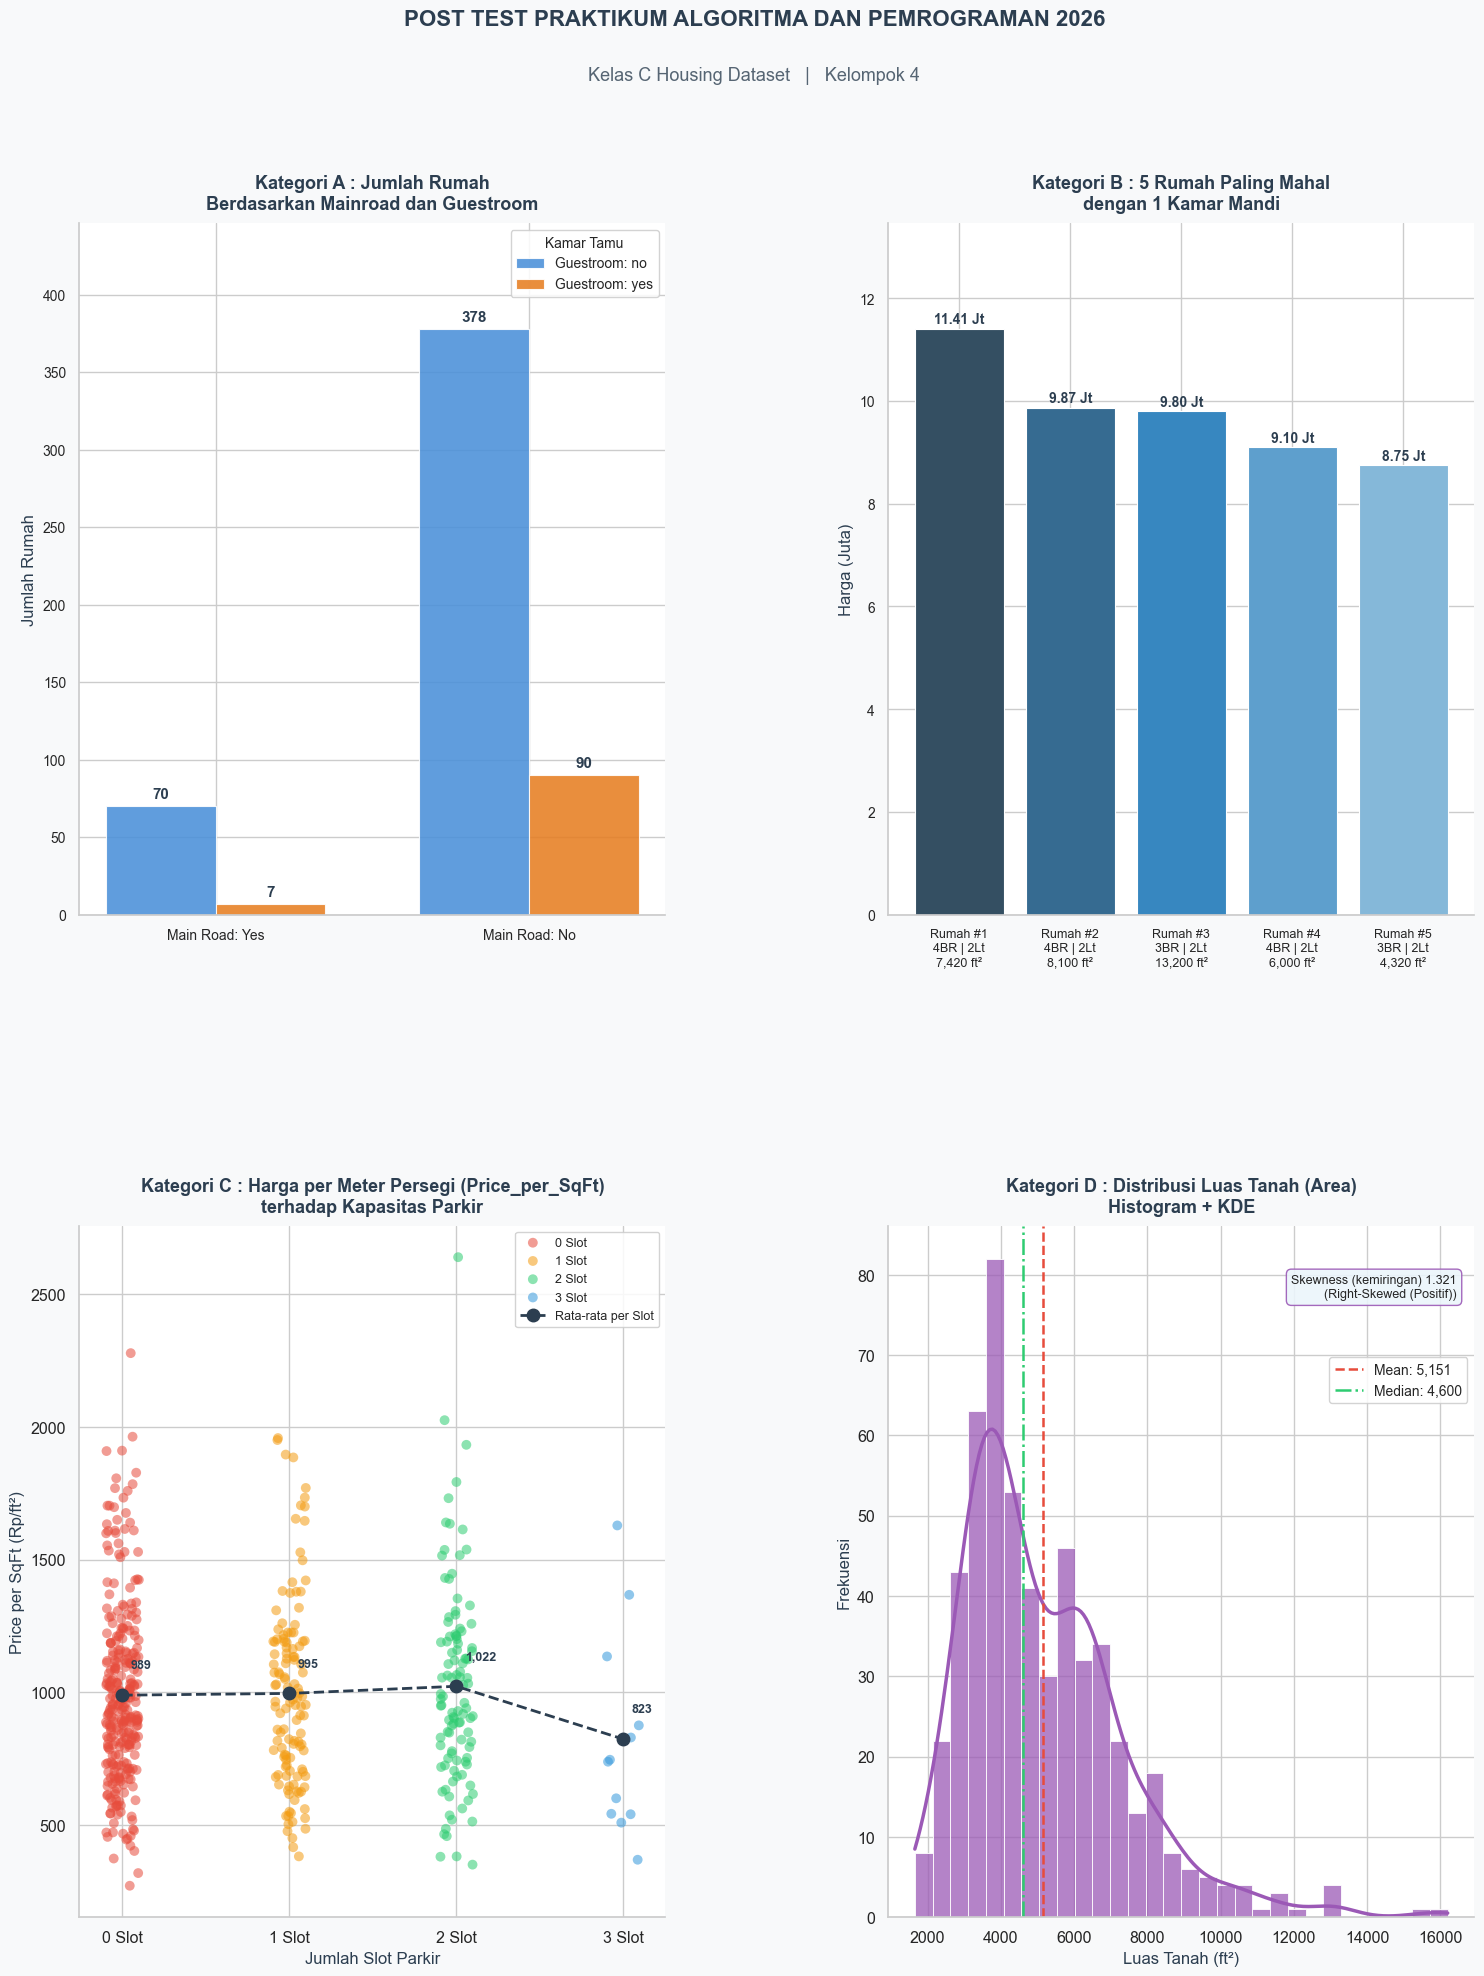

Done!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

# ── Load dataset ──────────────────────────────────────────────────────
df = pd.read_csv("Kelas C_Housing.csv")

# ── Global style ──────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.05)
BLUE   = "#4A90D9"
GREEN  = "#2ECC71"
ORANGE = "#E67E22"
PURPLE = "#9B59B6"
RED    = "#E74C3C"
ACCENT = "#2C3E50"

fig = plt.figure(figsize=(18, 22))
fig.patch.set_facecolor('#F8F9FA')
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.38)


# ============================================================
# KATEGORI A — Grouped Bar Chart
# Total jumlah rumah berdasarkan kombinasi mainroad × guestroom
# ============================================================
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor('#FFFFFF')

grp_a = (df.groupby(['mainroad', 'guestroom'])
           .size()
           .reset_index(name='count'))

x_labels = grp_a['mainroad'].unique()
x = np.arange(len(x_labels))
width = 0.35
guestroom_vals = grp_a['guestroom'].unique()
colors_a = [BLUE, ORANGE]

for i, groom in enumerate(guestroom_vals):
    sub = grp_a[grp_a['guestroom'] == groom]
    counts = [sub[sub['mainroad'] == ml]['count'].values[0]
              if ml in sub['mainroad'].values else 0
              for ml in x_labels]
    bars = ax1.bar(x + i * width - width / 2, counts, width,
                   label=f'Guestroom: {groom}',
                   color=colors_a[i], edgecolor='white', linewidth=0.8,
                   alpha=0.88)
    for bar, val in zip(bars, counts):
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
                 str(val), ha='center', va='bottom', fontsize=11,
                 fontweight='bold', color=ACCENT)

ax1.set_xticks(x)
ax1.set_xticklabels(['Main Road: Yes', 'Main Road: No'], fontsize=12)
ax1.set_ylabel('Jumlah Rumah', fontsize=12, color=ACCENT)
ax1.set_title('Kategori A : Jumlah Rumah\nBerdasarkan Mainroad dan Guestroom',
              fontsize=13, fontweight='bold', color=ACCENT, pad=10)
ax1.legend(title='Kamar Tamu', fontsize=10, title_fontsize=10,
           framealpha=0.85, loc='upper right')
ax1.set_ylim(0, grp_a['count'].max() * 1.18)
ax1.tick_params(axis='both', labelsize=10)
ax1.spines[['top', 'right']].set_visible(False)


# ============================================================
# KATEGORI B — Bar Chart
# 5 rumah paling mahal dengan hanya 1 kamar mandi
# ============================================================
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor('#FFFFFF')

top5 = (df[df['bathrooms'] == 1]
        .nlargest(5, 'price')
        .reset_index(drop=True))
top5['label'] = [f'Rumah #{i + 1}\n{row.bedrooms}BR | {row.stories}Lt\n{row.area:,} ft²'
                 for i, row in top5.iterrows()]
top5['price_jt'] = top5['price'] / 1e6

palette_b = sns.color_palette("Blues_d", n_colors=5)[::-1]
bars = ax2.bar(top5['label'], top5['price_jt'],
               color=palette_b, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, top5['price_jt']):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
             f'{val:.2f} Jt', ha='center', va='bottom',
             fontsize=10, fontweight='bold', color=ACCENT)

ax2.set_ylabel('Harga (Juta)', fontsize=12, color=ACCENT)
ax2.set_title('Kategori B : 5 Rumah Paling Mahal\ndengan 1 Kamar Mandi',
              fontsize=13, fontweight='bold', color=ACCENT, pad=10)
ax2.set_ylim(0, top5['price_jt'].max() * 1.18)
ax2.tick_params(axis='x', labelsize=9)
ax2.tick_params(axis='y', labelsize=10)
ax2.spines[['top', 'right']].set_visible(False)


# ============================================================
# KATEGORI C — Scatter Plot
# Hitung Price_per_SqFt = price / area, hubungkan dengan parking
# ============================================================
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_facecolor('#FFFFFF')

df['Price_per_SqFt'] = df['price'] / df['area']

parking_colors = {0: '#E74C3C', 1: '#F39C12', 2: '#2ECC71', 3: '#3498DB'}
parking_labels = {0: '0 Slot', 1: '1 Slot', 2: '2 Slot', 3: '3 Slot'}

for park_val, grp in df.groupby('parking'):
    ax3.scatter(grp['parking'] + np.random.uniform(-0.1, 0.1, len(grp)),
                grp['Price_per_SqFt'],
                color=parking_colors[park_val],
                alpha=0.55, s=50, edgecolors='none',
                label=parking_labels[park_val])

# Garis rata-rata per kelompok parkir
means = df.groupby('parking')['Price_per_SqFt'].mean()
ax3.plot(means.index, means.values, 'o--',
         color=ACCENT, linewidth=2, markersize=9,
         zorder=5, label='Rata-rata per Slot')
for x_val, y_val in zip(means.index, means.values):
    ax3.text(x_val + 0.05, y_val + 100,
             f'{y_val:,.0f}', fontsize=9, color=ACCENT, fontweight='bold')

ax3.set_xlabel('Jumlah Slot Parkir', fontsize=12, color=ACCENT)
ax3.set_ylabel('Price per SqFt (Rp/ft²)', fontsize=12, color=ACCENT)
ax3.set_title('Kategori C : Harga per Meter Persegi (Price_per_SqFt)\nterhadap Kapasitas Parkir',
              fontsize=13, fontweight='bold', color=ACCENT, pad=10)
ax3.set_xticks([0, 1, 2, 3])
ax3.set_xticklabels(['0 Slot', '1 Slot', '2 Slot', '3 Slot'])
ax3.legend(fontsize=9, framealpha=0.85)
ax3.spines[['top', 'right']].set_visible(False)


# ============================================================
# KATEGORI D — Histogram + KDE
# Distribusi luas tanah (area) untuk melihat kemencengan data
# ============================================================
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_facecolor('#FFFFFF')

sns.histplot(df['area'], bins=30, kde=True, ax=ax4,
             color=PURPLE, edgecolor='white', linewidth=0.6,
             alpha=0.75, line_kws={'linewidth': 2.5, 'color': '#6C3483'})

mean_area   = df['area'].mean()
median_area = df['area'].median()
skew_val    = df['area'].skew()

ax4.axvline(mean_area,   color=RED,   linestyle='--', linewidth=1.8,
            label=f'Mean: {mean_area:,.0f}')
ax4.axvline(median_area, color=GREEN, linestyle='-.', linewidth=1.8,
            label=f'Median: {median_area:,.0f}')

ax4.set_xlabel('Luas Tanah (ft²)', fontsize=12, color=ACCENT)
ax4.set_ylabel('Frekuensi', fontsize=12, color=ACCENT)
ax4.set_title('Kategori D : Distribusi Luas Tanah (Area)\nHistogram + KDE',
              fontsize=13, fontweight='bold', color=ACCENT, pad=10)
ax4.legend(fontsize=10, framealpha=0.85)
ax4.legend(fontsize=10, 
          framealpha=0.85, 
          loc='upper right', 
          bbox_to_anchor=(1, 0.82))

skew_dir = ("Right-Skewed (Positif)" if skew_val > 0.5 else
            "Left-Skewed (Negatif)" if skew_val < -0.5 else "Simetris")
ax4.text(0.97, 0.93, f'Skewness (kemiringan) {skew_val:.3f}\n({skew_dir})',
         transform=ax4.transAxes, fontsize=9, ha='right', va='top',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#EBF5FB',
                   edgecolor=PURPLE, alpha=0.9))
ax4.spines[['top', 'right']].set_visible(False)


# ── Judul utama ───────────────────────────────────────────────────────
fig.text(0.5, 0.97,
         'POST TEST PRAKTIKUM ALGORITMA DAN PEMROGRAMAN 2026',
         ha='center', fontsize=16, fontweight='bold', color=ACCENT)
fig.text(0.5, 0.945,
         'Kelas C Housing Dataset   |   Kelompok 4',
         ha='center', fontsize=13, color='#566573')

plt.savefig('Kelompok4_KelasC_PostTest.png', dpi=160, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("Done!")